In [15]:
print("Hello Angela!")

Hello Angela!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("retail_sales_dataset.csv")

In [6]:
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


# Exploratory Data Analysis (EDA) on Retail Sales Dataset

## Initial Inspection

In [7]:
df.shape

(4310, 21)

In [8]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'age',
       'gender', 'region', 'city', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit',
       'shipping_cost', 'payment_method', 'customer_satisfaction',
       'return_flag', 'order_status', 'days_to_ship'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   str    
 1   order_date             4280 non-null   str    
 2   customer_id            4280 non-null   str    
 3   customer_name          4280 non-null   str    
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   str    
 6   region                 4280 non-null   str    
 7   city                   4280 non-null   str    
 8   product_category       4280 non-null   str    
 9   product_name           4280 non-null   str    
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  shipping_cost  

In [10]:
df.isnull().sum()

order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(109)

In [12]:
df.describe()

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
count,4150.000000,4170.000000,4280.000000,4143.000000,4.280000e+03,4.280000e+03,4280.000000,3932.000000,4180.000000
mean,35.335181,7.379856,10621.154428,0.202085,6.235864e+04,1.168713e+04,63.358836,3.016531,5.620335
std,35.709382,43.578352,17323.704016,0.118095,3.166998e+05,5.287522e+04,18.312281,1.413127,4.178663
min,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000
25%,26.000000,3.000000,672.222500,0.100000,2.462165e+03,7.018225e+02,50.817500,2.000000,3.000000
50%,34.000000,5.000000,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,3.000000,6.000000
75%,42.000000,8.000000,12717.435000,0.310000,5.006964e+04,1.040372e+04,75.650000,4.000000,8.000000
max,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000


### Observation

- The dataset contains multiple customer, product, and sales-related variables.
- The initial inspection identified the data types of each column.
- Missing values are present in some columns and will need to be handled during data cleaning.
- Duplicate rows should be removed before further analysis.

In [13]:
df.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'customer_name',
 'age',
 'gender',
 'region',
 'city',
 'product_category',
 'product_name',
 'quantity',
 'unit_price',
 'discount_pct',
 'sales_amount',
 'profit',
 'shipping_cost',
 'payment_method',
 'customer_satisfaction',
 'return_flag',
 'order_status',
 'days_to_ship']

# Time Series Analysis

In [48]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [16]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True
)

In [17]:
df["order_date"].isna().sum()

np.int64(30)

In [18]:
df[df["order_date"].isna()]

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
66,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
144,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
432,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
516,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
630,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
986,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1038,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1517,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1532,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1765,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
df = df.dropna(how="all")

In [21]:
df.shape

(4280, 21)

In [22]:
df["order_date"].isna().sum()

np.int64(0)

In [23]:
df = df.drop_duplicates()

In [24]:
df.duplicated().sum()

np.int64(0)

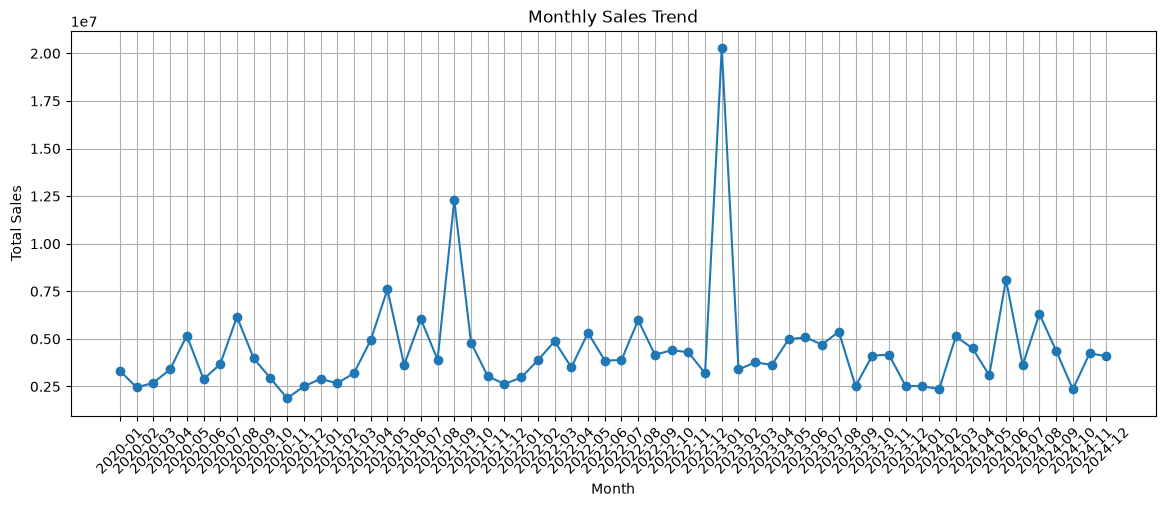

In [31]:
monthly_sales = df.groupby(df["order_date"].dt.to_period("M"))["sales_amount"].sum()  

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

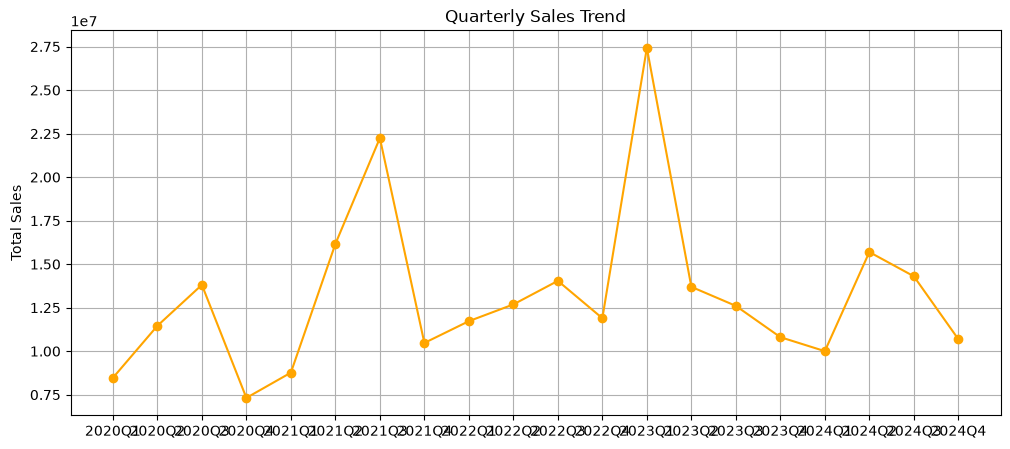

In [30]:
quarterly_sales = df.groupby(df["order_date"].dt.to_period("Q"))["sales_amount"].sum()

quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o', color='orange')
plt.title("Quarterly Sales Trend")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

## Observation

- The monthly sales trend shows how sales fluctuate over time.
- The quarterly trend helps identify seasonal patterns and business performance across different quarters.
- These trends can guide inventory planning and promotional campaigns during peak and low sales periods.

# Customer Demographics Analysis

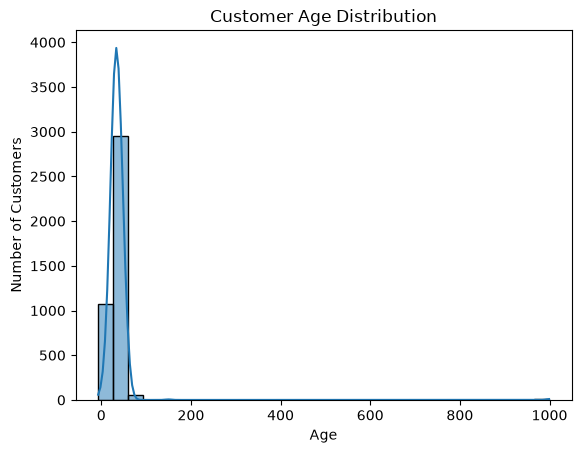

In [38]:
plt.Figure(figsize=(10, 5))
sns.histplot(df["age"], bins=30, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

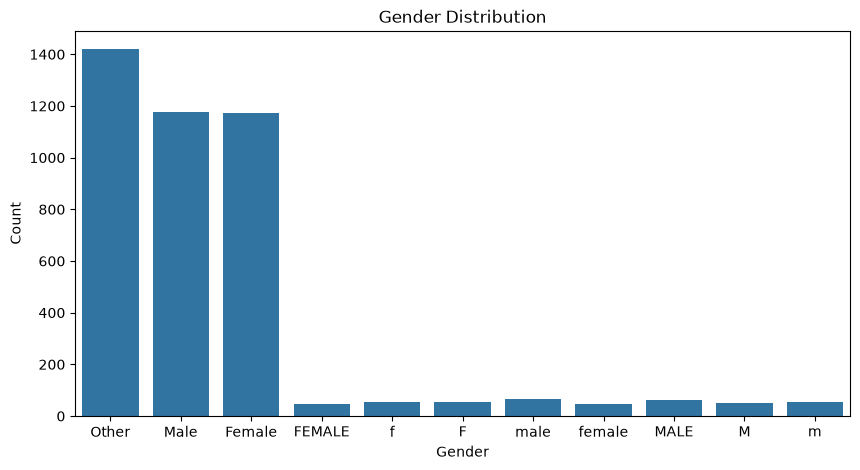

In [40]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## Observation

- The age distribution identifies the dominant customer age group.
- The gender chart shows the proportion of cutomers by gender.
- These insights can support targeted marketing campaigns.

# Product Analysis

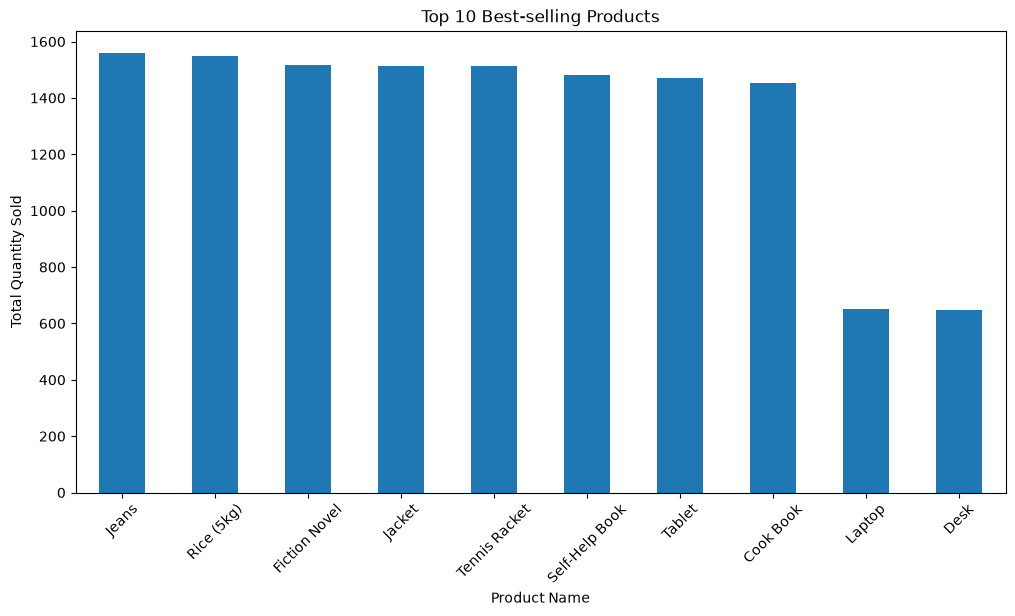

In [42]:
top_products = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top_products.plot(kind="bar")

plt.title("Top 10 Best-selling Products")
plt.xlabel("Product Name")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

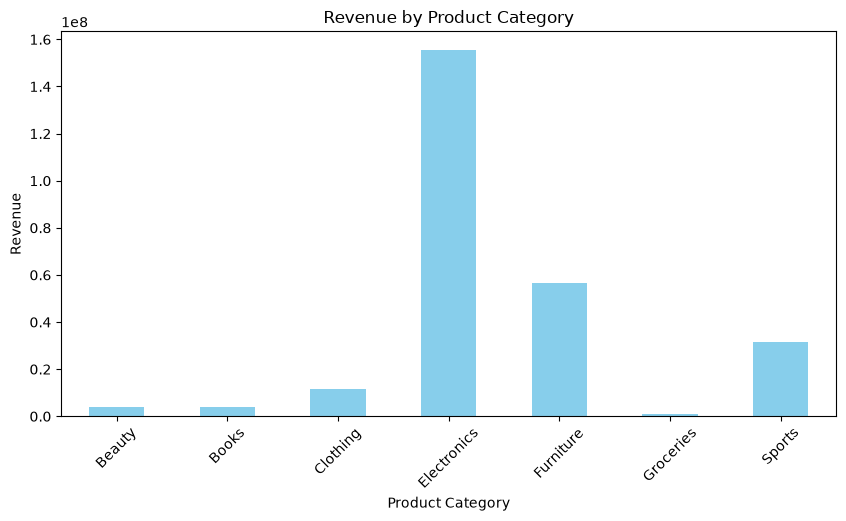

In [44]:
category_sales = df.groupby("product_category")["sales_amount"].sum()

plt.figure(figsize=(10, 5))
category_sales.plot(kind="bar", color="skyblue")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Observation

- Some products contribute significantly more sales than others.
- Product categories generate different levels of revenue.
- High-performing categories should rceive more marketing attention and inventory allocation.

# Correlation Heatmap

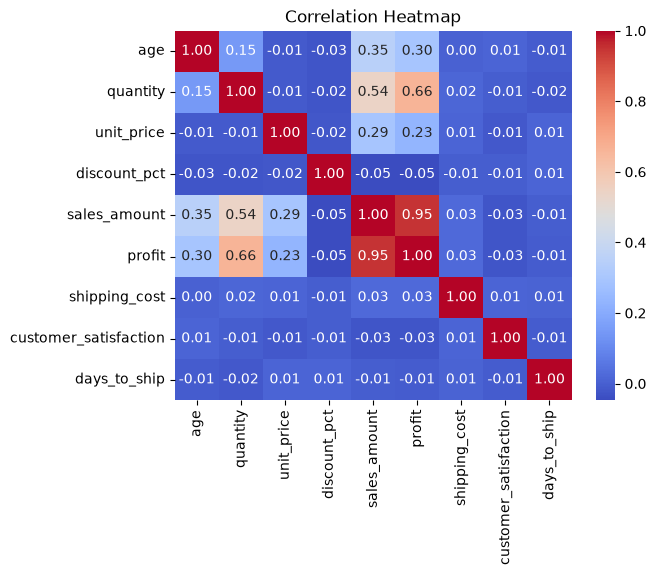

In [46]:
plt.Figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Observation

- Strong positive correlations indicate variablles that increase together.
- Weak or negative correlations inndicate little or inverse relationships.
- Correlation helps identify factors influencing sales and profitability.

# Customer Satisfaction vs Sales

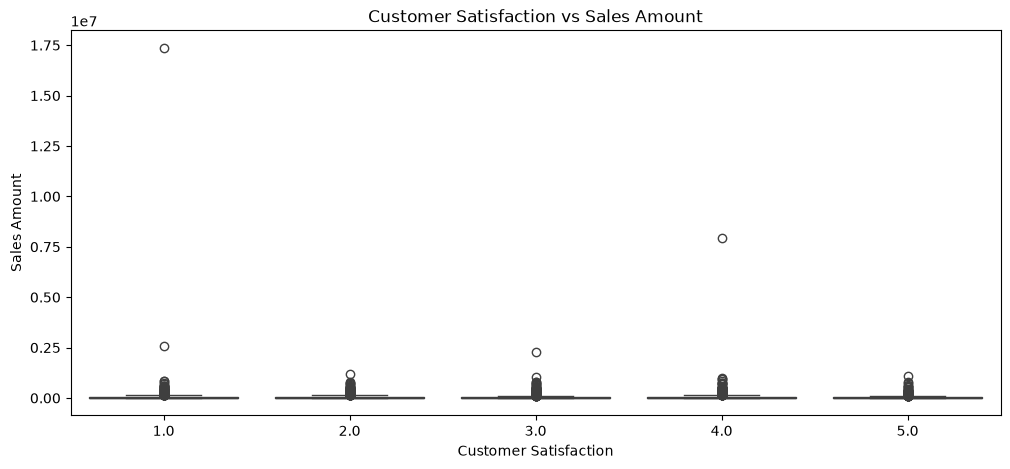

In [47]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="customer_satisfaction",
    y="sales_amount"
)

plt.title("Customer Satisfaction vs Sales Amount")
plt.xlabel("Customer Satisfaction")
plt.ylabel("Sales Amount")
plt.show()

## Observation

- The visualization helps determine whether higher customer satisfaction is associated with larger sales.
- This insight can guide customer experience improvement strategies.

# Conclusion

## Key findings

- Sales vary acrosss months and quarters, indicatiing seasonal trends.
- Customer demographics reveal difference in age and gender distribution.
- Certain products and product categories contribute more revenue than others.
- Numerical  variables show meaningful relationships through the correlation analyis.
- Customer satisfaction may influence purchasing behaviour and sales performance.

## Business Recommendations

1. Increase inventory for the highest-selling products to prevent stock shortages.

2. Introduce targeted marketing campaign during low-sales periods to improve revenue consistency.

3. Improve customer satisfaction through better service and product quality, as satisfied customers may contribute to higher sales.